# FPCL - Feature Pyramid Contrastive Learning (AAAI 2024)
## Dental Disease Detection on YOLOv8 format Dentex Dataset
### Paper: CariesXrays: Enhancing Caries Detection via Feature Pyramid Contrastive Learning

**Key Components:**
- **D2D-FPN Neck**: Dual-Directional FPN with Multi-scale Attention Fusion (MAF) to fuse high and low resolution features.
- **P2P-CRL Head**: Point-to-Point Contrastive Representation Learning using Sub-pixel Convolution (PixelShuffle) and projection head.
- **Momentum-based Dynamic Update**: Updates the weight of contrastive loss dynamically based on the detection loss difference.
- **VRAM Optimizations**: Batch size = 1 with gradient accumulation = 4, activation checkpointing on D2D-FPN layer, and capping matched proposals to 32 to prevent OOM on Kaggle T4 GPU.

In [1]:
!pip install -q torchvision tqdm matplotlib pycocotools
import os, json, math, random, time, numpy as np
from PIL import Image
from collections import defaultdict
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
import torchvision.models
from torchvision.ops import MultiScaleRoIAlign, roi_align
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
from tqdm import tqdm
from torch.utils.checkpoint import checkpoint

print("PyTorch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
if torch.cuda.is_available(): print("GPU:", torch.cuda.get_device_name(0))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch: 2.10.0+cu128 | CUDA: True
GPU: Tesla T4


## Configurations

In [2]:
class Config:
    import os
    BASE_DIR = "/kaggle/input"
    
    # Auto-detect dataset directory containing 'train/images' recursively on Kaggle
    if os.path.exists("/kaggle/input"):
        found_path = None
        # Get all subdirectories in /kaggle/input
        for d in os.listdir("/kaggle/input"):
            subdir_path = os.path.join("/kaggle/input", d)
            if os.path.isdir(subdir_path):
                # Check if train/images is directly inside
                if os.path.exists(os.path.join(subdir_path, "train/images")):
                    found_path = subdir_path
                    break
                # Otherwise search recursively using os.walk (works with mounts)
                for root, dirs, files in os.walk(subdir_path):
                    if "train" in dirs and os.path.exists(os.path.join(root, "train/images")):
                        found_path = root
                        break
                if found_path:
                    break
        if found_path:
            BASE_DIR = found_path
        else:
            BASE_DIR = "/kaggle/input"
    else:
        # Fallback local
        BASE_DIR = "C:/Users/Administrator/Desktop/PBL_datasetmoi/dentex dataset.v3i.yolov8"
        
    if not os.path.exists(BASE_DIR):
        BASE_DIR = "C:/Users/Administrator/Desktop/PBL_datasetmoi/YOLOv8_Dentex_2023"
        
    TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train/images")
    TRAIN_LABEL_DIR = os.path.join(BASE_DIR, "train/labels")
    
    VAL_IMG_DIR = os.path.join(BASE_DIR, "valid/images")
    VAL_LABEL_DIR = os.path.join(BASE_DIR, "valid/labels")
    
    SAVE_DIR = "/kaggle/working/fpcl_checkpoints"
    if not os.path.exists("/kaggle/working"):
        SAVE_DIR = "./fpcl_checkpoints"
        
    CLASSES = ['Caries', 'Deep Caries', 'Impacted', 'Periapical Lesion']
    NUM_CLASSES = 5  # Background + 4 classes
    
    # Batch size & accumulation
    BATCH_SIZE = 4
    GRAD_ACCUMULATION = 2
    
    LR = 2e-4
    WEIGHT_DECAY = 1e-4
    NUM_EPOCHS = 50
    MAX_SIZE = 1024
    FPN_CHANNELS = 256
    CL_FEAT_DIM = 128
    SMOOTH_ALPHA = 0.5
    FPN_DEPTH = 3
    LAMBDA_INIT = 0.3
    PROPOSAL_SIZE = 7
    USE_CROSS_CLASS_NMS = False

os.makedirs(Config.SAVE_DIR, exist_ok=True)
print("Config setup done. Dataset path:", Config.BASE_DIR)

Config setup done. Dataset path: /kaggle/input/datasets/quannene/dentenyolov8-3i


## Dataset Loader for YOLO format
The custom dataset class parses the YOLO polygon/bounding box annotations, de-normalizes them into absolute pixel values, and filters out images without annotations to ensure stable contrastive learning.

In [3]:
import os
import random
from collections import defaultdict
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2

def parse_yolo_line(line):
    parts = line.strip().split()
    if len(parts) < 5:
        return None
    class_id = int(parts[0])
    coords = [float(x) for x in parts[1:]]
    if len(coords) == 4:
        x_center, y_center, w, h = coords
        xmin = x_center - w / 2
        ymin = y_center - h / 2
        xmax = x_center + w / 2
        ymax = y_center + h / 2
        return class_id, xmin, ymin, xmax, ymax
    elif len(coords) >= 6 and len(coords) % 2 == 0:
        xs = coords[0::2]
        ys = coords[1::2]
        xmin = min(xs)
        ymin = min(ys)
        xmax = max(xs)
        ymax = max(ys)
        return class_id, xmin, ymin, xmax, ymax
    return None

def prepare_dataset_splits(base_dir):
    # 1. Quet toan bo cac file anh hop le tu train goc
    train_img_dir = os.path.join(base_dir, "train/images")
    train_label_dir = os.path.join(base_dir, "train/labels")
    
    train_files = []
    if os.path.exists(train_img_dir):
        for f in os.listdir(train_img_dir):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                base = os.path.splitext(f)[0]
                lp = os.path.join(train_label_dir, base + '.txt')
                if os.path.exists(lp):
                    has_valid_box = False
                    with open(lp, 'r') as lf:
                        for line in lf:
                            res = parse_yolo_line(line)
                            if res is not None:
                                class_id, xmin, ymin, xmax, ymax = res
                                if xmax > xmin and ymax > ymin:
                                    has_valid_box = True
                                    break
                    if has_valid_box:
                        train_files.append((f, os.path.abspath(os.path.join(train_img_dir, f)), os.path.abspath(lp)))

    # 2. Nhom anh theo ten goc cua train (tranh leakage do Roboflow offline augmentations)
    def get_base_name(filename):
        base = os.path.splitext(filename)[0]
        if '.rf.' in base:
            base = base.split('.rf.')[0]
        return base

    groups = defaultdict(list)
    for f, img_p, lbl_p in train_files:
        bname = get_base_name(f)
        groups[bname].append((img_p, lbl_p))

    group_keys = sorted(list(groups.keys()))
    random.seed(42)
    random.shuffle(group_keys)

    # Rut ra 100 nhom de lam Validation/Test pool, con lai de train
    n_groups = len(group_keys)
    eval_groups_count = min(100, n_groups)
    eval_group_keys = group_keys[:eval_groups_count]
    train_group_keys = group_keys[eval_groups_count:]

    train_samples = []
    for k in train_group_keys:
        train_samples.extend(groups[k])

    # Ap dung oversampling cho cac lop hiem trong train_samples
    oversampled_train_samples = []
    for img_p, lbl_p in train_samples:
        classes_in_file = set()
        with open(lbl_p, 'r') as lf:
            for line in lf:
                res = parse_yolo_line(line)
                if res is not None:
                    classes_in_file.add(res[0])
        
        repeat = 1
        if 3 in classes_in_file:  # Periapical Lesion (Class 3)
            repeat = max(repeat, 3)
        elif 1 in classes_in_file:  # Deep Caries (Class 1)
            repeat = max(repeat, 2)
            
        for _ in range(repeat):
            oversampled_train_samples.append((img_p, lbl_p))
            
    train_samples = oversampled_train_samples

    eval_pool = []
    for k in eval_group_keys:
        # Chi lay 1 anh dai dien de tranh duplicate/leak
        eval_pool.append(groups[k][0])

    # 3. Quet toan bo file tu tap valid goc cua Roboflow
    test_img_dir = os.path.join(base_dir, "valid/images")
    test_label_dir = os.path.join(base_dir, "valid/labels")
    
    valid_original_files = []
    if os.path.exists(test_img_dir):
        for f in os.listdir(test_img_dir):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                base = os.path.splitext(f)[0]
                lp = os.path.join(test_label_dir, base + '.txt')
                if os.path.exists(lp):
                    has_valid_box = False
                    with open(lp, 'r') as lf:
                        for line in lf:
                            res = parse_yolo_line(line)
                            if res is not None:
                                class_id, xmin, ymin, xmax, ymax = res
                                if xmax > xmin and ymax > ymin:
                                    has_valid_box = True
                                    break
                    if has_valid_box:
                        valid_original_files.append((os.path.abspath(os.path.join(test_img_dir, f)), os.path.abspath(lp)))

    # Gop 100 anh tu train va tat ca anh tu valid goc thanh mot pool duy nhat
    eval_pool.extend(valid_original_files)

    # Tron deu va chia doi 50/50 de duoc tap Val va Test bang nhau
    random.seed(42)
    random.shuffle(eval_pool)

    mid = len(eval_pool) // 2
    val_samples = eval_pool[:mid]
    test_samples = eval_pool[mid:]

    print(f"Tong so nhom anh goc trong Train: {n_groups}")
    print(f"Tong so anh sach trong Evaluation Pool: {len(eval_pool)} (100 tu train + {len(valid_original_files)} tu valid goc)")
    print(f"Da phan chia tranh Data Leak (Val & Test bang nhau, co oversampling):")
    print(f"  - Train: {len(train_samples)} files (da oversample tu {len(train_group_keys)} nhom)")
    print(f"  - Val:   {len(val_samples)} files (sach, khong augmented)")
    print(f"  - Test:  {len(test_samples)} files (sach, khong augmented)")
    
    return train_samples, val_samples, test_samples

class YOLOv8DentexDataset(Dataset):
    def __init__(self, samples, tfms=None, train=False):
        self.samples = samples
        self.tfms = tfms
        self.train = train
        
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        img_path, label_path = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        w_img, h_img = img.size
        img_np = np.array(img)
        
        boxes, labels = [], []
        with open(label_path, 'r') as f:
            for line in f:
                res = parse_yolo_line(line)
                if res is None: continue
                class_id, xmin, ymin, xmax, ymax = res
                if xmax <= xmin or ymax <= ymin: continue
                
                xmin_abs = max(0.0, min(xmin * w_img, float(w_img)))
                ymin_abs = max(0.0, min(ymin * h_img, float(h_img)))
                xmax_abs = max(0.0, min(xmax * w_img, float(w_img)))
                ymax_abs = max(0.0, min(ymax * h_img, float(h_img)))
                
                if (xmax_abs - xmin_abs) < 1.0 or (ymax_abs - ymin_abs) < 1.0:
                    continue
                
                boxes.append([xmin_abs, ymin_abs, xmax_abs, ymax_abs])
                labels.append(class_id + 1)
                
        # Neu khong co box nao, ta tao 1 box fake rat nho o goc (Faster R-CNN bat buoc phai co box)
        if len(boxes) == 0:
            boxes = [[0.0, 0.0, 1.0, 1.0]]
            labels = [1]
            
        if self.tfms:
            transformed = self.tfms(image=img_np, bboxes=boxes, class_labels=labels)
            img_tensor = transformed['image'] / 255.0  # Normalize to [0, 1]
            boxes = transformed['bboxes']
            labels = transformed['class_labels']
            
            # Format back to tensors
            bx = torch.as_tensor(boxes, dtype=torch.float32)
            lb = torch.as_tensor(labels, dtype=torch.int64)
        else:
            img_tensor = torch.as_tensor(img_np.transpose(2, 0, 1), dtype=torch.float32) / 255.0
            bx = torch.as_tensor(boxes, dtype=torch.float32)
            lb = torch.as_tensor(labels, dtype=torch.int64)
            
        tgt = {
            "boxes": bx,
            "labels": lb,
            "image_id": torch.tensor([idx]),
            "area": (bx[:, 2] - bx[:, 0]) * (bx[:, 3] - bx[:, 1]) if len(bx) > 0 else torch.zeros(0),
            "iscrowd": torch.zeros(len(bx), dtype=torch.int64)
        }
        return img_tensor, tgt

def get_transform(train=True):
    if train:
        return A.Compose([
            A.LongestMaxSize(max_size=1024),
            A.HorizontalFlip(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=10, border_mode=0, p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8), p=1.0),
            A.GaussianBlur(blur_limit=(3, 5), p=0.3),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'], min_area=1, clip=True))
    else:
        return A.Compose([
            A.LongestMaxSize(max_size=1024),
            A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8), p=1.0),  # Luon ap dung CLAHE de dong bo anh test/val
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'], min_area=1, clip=True))

def collate_fn(batch):
    return tuple(zip(*batch))

## D2D-FPN with MAF (Eq. 1-2)
Includes GroupNorm for batch-size independent training and memory checkpointing to save VRAM.

In [4]:
class MAFBlock(nn.Module):
    def __init__(self, channels=256):
        super().__init__()
        self.w1 = nn.Parameter(torch.ones(1))
        self.w2 = nn.Parameter(torch.ones(1))
        self.smooth = nn.Conv2d(channels, channels, 3, padding=1)
        
    def forward(self, f1, f2):
        w1 = F.relu(self.w1)
        w2 = F.relu(self.w2)
        ws = w1 + w2 + 1e-4
        return self.smooth(w1/ws * f1 + w2/ws * f2)

class D2DFPN(nn.Module):
    def __init__(self, in_ch_list, out_ch=256, depth=3):
        super().__init__()
        self.laterals = nn.ModuleList([nn.Conv2d(c, out_ch, 1) for c in in_ch_list])
        n = len(in_ch_list)
        self.td_maf = nn.ModuleList([MAFBlock(out_ch) for _ in range(n-1)])
        self.bu_maf = nn.ModuleList([MAFBlock(out_ch) for _ in range(n-1)])
        self.bu_down = nn.ModuleList([nn.Conv2d(out_ch, out_ch, 3, stride=2, padding=1) for _ in range(n-1)])
        self.skip_conv = nn.ModuleList([nn.Sequential(
            nn.Conv2d(out_ch, out_ch, 1),
            nn.GroupNorm(32, out_ch)
        ) for _ in range(n)])
        
        self.refine = nn.ModuleList()
        for _ in range(depth-1):
            self.refine.append(nn.Sequential(
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.GroupNorm(32, out_ch),
                nn.ReLU(True)
            ))
            
    def forward(self, features):
        def _inner_forward(*fl):
            lats = [c(f) for c, f in zip(self.laterals, fl)]
            td = [None] * len(lats)
            td[-1] = lats[-1]
            for i in range(len(lats) - 2, -1, -1):
                up = F.interpolate(td[i+1], size=lats[i].shape[2:], mode='bilinear', align_corners=False)
                td[i] = self.td_maf[i](lats[i], up)
            bu = [None] * len(td)
            bu[0] = td[0]
            for i in range(len(td) - 1):
                down = self.bu_down[i](bu[i])
                if down.shape[2:] != td[i+1].shape[2:]:
                    down = F.interpolate(down, size=td[i+1].shape[2:], mode='bilinear', align_corners=False)
                bu[i+1] = self.bu_maf[i](td[i+1], down)
            out = [bu[i] + self.skip_conv[i](lats[i]) for i in range(len(bu))]
            for ref in self.refine:
                out = [ref(f) for f in out]
            return out
            
        fl = list(features.values()) if isinstance(features, dict) else features
        if self.training:
            return checkpoint(_inner_forward, *fl, use_reentrant=False)
        else:
            return _inner_forward(*fl)

## P2P-CRL (Eq. 4-6)
Sub-pixel convolution (PixelShuffle) is used to map proposal features into the contrastive learning embedding space.

In [5]:
class SubPixelNorm(nn.Module):
    def __init__(self, channels=256, r=2):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels * r * r, 1)
        self.shuffle = nn.PixelShuffle(r)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.norm = nn.Sequential(
            nn.Linear(channels, channels),
            nn.LayerNorm(channels),
            nn.ReLU(True)
        )
        
    def forward(self, x):
        x = self.shuffle(self.conv(x))
        return self.norm(self.pool(x).flatten(1))

class P2PCRL(nn.Module):
    def __init__(self, in_ch=256, feat_dim=128, num_classes=5):
        super().__init__()
        self.subpixel = SubPixelNorm(in_ch)
        self.projector = nn.Sequential(
            nn.Linear(in_ch, in_ch),
            nn.ReLU(True),
            nn.Linear(in_ch, feat_dim)
        )
        self.level_weights = nn.ParameterList([nn.Parameter(torch.tensor(1.0)) for _ in range(4)])
        self.delta = 1e-6
        
    def forward(self, roi_feats_list, labels_list):
        dev = roi_feats_list[0].device if len(roi_feats_list) > 0 else 'cpu'
        total = torch.tensor(0.0, device=dev)
        for i, (feats, labels) in enumerate(zip(roi_feats_list, labels_list)):
            if i >= 4 or len(labels) == 0: continue
            normed = self.subpixel(feats)
            proj = F.normalize(self.projector(normed), dim=1)
            unique_cls = labels.unique()
            
            prototypes = {}
            for cls in unique_cls:
                prototypes[cls.item()] = F.normalize(proj[labels == cls].mean(0, keepdim=True), dim=1)
                
            if len(prototypes) >= 2:
                proto_ids = sorted(prototypes.keys())
                proto_stack = torch.cat([prototypes[c] for c in proto_ids], dim=0)
                all_sims = torch.mm(proj, proto_stack.t()) / 0.07
                
                pos_mask = torch.zeros_like(all_sims)
                for k, c in enumerate(proto_ids):
                    pos_mask[labels == c, k] = 1.0
                pos_sims = (all_sims * pos_mask).sum(1)
                loss_lvl = (-pos_sims + torch.logsumexp(all_sims, dim=1)).mean()
            elif len(prototypes) == 1:
                proto = list(prototypes.values())[0]
                sim = (proj * proto).sum(1).clamp(min=1e-7)
                loss_lvl = (-torch.log(sim)).mean()
            else:
                continue
                
            total = total + F.relu(self.level_weights[i]) * (loss_lvl + self.delta)
        return total

## FPCL Model Backbone and Model Wrapper
Loads COCO pretrained weights for Transfer Learning on the RPN and RoI box heads.

In [6]:
from torchvision.models._utils import IntermediateLayerGetter
from collections import OrderedDict as OD
from torchvision.ops import box_iou

class FPCLBackbone(nn.Module):
    def __init__(self, fpn_depth=3):
        super().__init__()
        resnet = torchvision.models.resnet50(weights='DEFAULT')
        self.body = IntermediateLayerGetter(resnet, {'layer1':'0','layer2':'1','layer3':'2','layer4':'3'})
        del resnet
        self.d2d_fpn = D2DFPN([256, 512, 1024, 2048], Config.FPN_CHANNELS, fpn_depth)
        self.out_channels = Config.FPN_CHANNELS
        
    def forward(self, x):
        raw = self.body(x)
        fpn_out = self.d2d_fpn(list(raw.values()))
        return OD([(str(i), f) for i, f in enumerate(fpn_out)])

class FPCLModel(nn.Module):
    def __init__(self, num_classes=5, fpn_depth=3):
        super().__init__()
        self.fpn_backbone = FPCLBackbone(fpn_depth)
        anchor_gen = AnchorGenerator(((32, 64), (64, 128), (128, 256), (256, 512)), ((0.5, 1.0, 2.0),)*4)
        roi_pool = MultiScaleRoIAlign(['0','1','2','3'], output_size=7, sampling_ratio=2)
        
        # Initialize detector
        self.detector = FasterRCNN(self.fpn_backbone, num_classes=num_classes,
            rpn_anchor_generator=anchor_gen, box_roi_pool=roi_pool,
            min_size=(640, 720, 800), max_size=Config.MAX_SIZE, rpn_score_thresh=0.05,
            box_score_thresh=0.05, box_nms_thresh=0.5)
            
        # Load COCO pretrained weights to speed up convergence
        try:
            pretrained_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')
            # Load RPN weights, skipping head classification/regression due to anchor shape mismatch
            rpn_state_dict = pretrained_model.rpn.state_dict()
            filtered_rpn_state_dict = {k: v for k, v in rpn_state_dict.items() if 'head.cls_logits' not in k and 'head.bbox_pred' not in k}
            self.detector.rpn.load_state_dict(filtered_rpn_state_dict, strict=False)
            # Load RoI heads weights, skipping final predictor due to class count mismatch
            roi_state_dict = pretrained_model.roi_heads.state_dict()
            filtered_roi_state_dict = {k: v for k, v in roi_state_dict.items() if 'box_predictor' not in k}
            self.detector.roi_heads.load_state_dict(filtered_roi_state_dict, strict=False)
            del pretrained_model, rpn_state_dict, filtered_rpn_state_dict, roi_state_dict, filtered_roi_state_dict
            import gc; gc.collect()
            print("Pretrained COCO weights loaded successfully (with shape-filtering)!")
        except Exception as e:
            print("Could not load COCO weights, training from scratch:", e)
            
        self.cl_head = P2PCRL(Config.FPN_CHANNELS, Config.CL_FEAT_DIM, num_classes)
        self.roi_size = Config.PROPOSAL_SIZE
        self._setup_hooks()
        
    def _setup_hooks(self):
        def _fpn_hook(m, inp, out):
            if self.training: m._cached_fpn = out
        def _rpn_hook(m, inp, out):
            if self.training: m._cached_proposals = out[0]
        def _tf_hook(m, inp, out):
            if self.training:
                m._cached_tshape = out[0].tensors.shape
                m._cached_tf_targets = out[1]
        self.detector.backbone.register_forward_hook(_fpn_hook)
        self.detector.rpn.register_forward_hook(_rpn_hook)
        self.detector.transform.register_forward_hook(_tf_hook)
        
    def _match_proposals_to_gt(self, proposals, gt_boxes, gt_labels, iou_th=0.3):
        if len(proposals) == 0 or len(gt_boxes) == 0:
            return torch.zeros(0,4,device=gt_boxes.device), torch.zeros(0,dtype=torch.int64,device=gt_boxes.device)
        ious = box_iou(proposals, gt_boxes)
        max_iou, match_idx = ious.max(dim=1)
        keep = max_iou >= iou_th
        if keep.sum() == 0:
            return torch.zeros(0,4,device=gt_boxes.device), torch.zeros(0,dtype=torch.int64,device=gt_boxes.device)
        matched_boxes = proposals[keep]
        matched_labels = gt_labels[match_idx[keep]]
        return matched_boxes, matched_labels
        
    def forward(self, images, targets=None):
        if len(images) == 0:
            if self.training:
                dev = next(self.parameters()).device
                return {
                    'loss_classifier': torch.tensor(0.0, device=dev, requires_grad=True),
                    'loss_box_reg': torch.tensor(0.0, device=dev, requires_grad=True),
                    'loss_objectness': torch.tensor(0.0, device=dev, requires_grad=True),
                    'loss_rpn_box_reg': torch.tensor(0.0, device=dev, requires_grad=True),
                    'loss_contrastive': torch.tensor(0.0, device=dev, requires_grad=True)
                }
            else:
                return []
        if self.training and targets is not None:
            det_losses = self.detector(images, targets)
            fpn_feats = self.detector.backbone._cached_fpn
            tf_targets = self.detector.transform._cached_tf_targets
            rpn_proposals = self.detector.rpn._cached_proposals
            
            rfl, lfl = [], []
            keys = sorted(fpn_feats.keys())[:4]
            for lvl, k in enumerate(keys):
                fm = fpn_feats[k]
                rl, ll = [], []
                for ii, props in enumerate(rpn_proposals):
                    gt_bx = tf_targets[ii]['boxes']
                    gt_lb = tf_targets[ii]['labels']
                    matched_bx, matched_lb = self._match_proposals_to_gt(props, gt_bx, gt_lb)
                    if len(matched_bx) == 0: continue
                    
                    # Cap contrastive proposals per level to 32 to avoid VRAM spikes
                    if len(matched_bx) > 32:
                        idx = torch.randperm(len(matched_bx))[:32]
                        matched_bx = matched_bx[idx]
                        matched_lb = matched_lb[idx]
                        
                    bi = torch.full((len(matched_bx), 1), ii, device=matched_bx.device, dtype=matched_bx.dtype)
                    rl.append(torch.cat([bi, matched_bx], 1))
                    ll.append(matched_lb)
                    
                if rl:
                    rf = roi_align(fm, torch.cat(rl), output_size=self.roi_size, spatial_scale=1.0/(2**(lvl+2)))
                    rfl.append(rf)
                    lfl.append(torch.cat(ll))
                else:
                    rfl.append(torch.zeros(0, Config.FPN_CHANNELS, self.roi_size, self.roi_size, device=fm.device))
                    lfl.append(torch.tensor([], dtype=torch.int64, device=fm.device))
                    
            det_losses['loss_contrastive'] = self.cl_head(rfl, lfl)
            
            self.detector.backbone._cached_fpn = None
            self.detector.rpn._cached_proposals = None
            self.detector.transform._cached_tshape = None
            self.detector.transform._cached_tf_targets = None
            return det_losses
        else:
            return self.detector(images, targets)

class FasterRCNNDataParallel(nn.DataParallel):
    def scatter(self, inputs, kwargs, device_ids):
        images = inputs[0]
        targets = inputs[1] if len(inputs) > 1 else None
        num_gpus = len(device_ids)
        batch_size = len(images)
        chunk_size = (batch_size + num_gpus - 1) // num_gpus
        scattered_inputs = []
        for i in range(num_gpus):
            start = i * chunk_size
            end = min(start + chunk_size, batch_size)
            if start < end:
                gpu_images = images[start:end]
                gpu_targets = targets[start:end] if targets is not None else None
                device = torch.device(f'cuda:{device_ids[i]}')
                gpu_images = [img.to(device) for img in gpu_images]
                if gpu_targets is not None:
                    gpu_targets = [{k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in t.items()} for t in gpu_targets]
                scattered_inputs.append((gpu_images, gpu_targets))
            else:
                scattered_inputs.append(([], None))
        return tuple(scattered_inputs), [{}] * len(device_ids)

class MomentumScheduler:
    def __init__(self, alpha=0.5, lam0=0.5):
        self.alpha, self.lam, self.prev = alpha, lam0, None
    def step(self, det_loss):
        if self.prev is not None:
            self.lam = max(0.0, min(0.4, self.lam + self.alpha * (self.prev - det_loss)))
        self.prev = det_loss
        return self.lam

## COCO Metric Evaluation (AP, AP50, AP75)
Evaluates validation set using standard COCO APIs. Includes Cross-Class NMS to remove redundant overlapping boxes.

In [7]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import numpy as np
import gc
import ctypes

def _release_memory():
    """Force Python to return freed memory back to OS (Linux only)."""
    gc.collect()
    try:
        ctypes.CDLL("libc.so.6").malloc_trim(0)
    except Exception:
        pass

def evaluate(model, loader, device):
    model.eval()
    coco_gt = {"images":[], "annotations":[], "categories":[]}
    for i, c in enumerate(Config.CLASSES):
        coco_gt["categories"].append({"id": i+1, "name": c})
    coco_dt = []
    ann_id, img_id = 0, 0
    
    with torch.no_grad():
        for imgs, tgts in tqdm(loader, desc="Eval"):
            outs = model([im.to(device) for im in imgs])
            for o, t in zip(outs, tgts):
                img_id += 1
                coco_gt["images"].append({"id": img_id})
                
                for b, l in zip(t['boxes'].numpy(), t['labels'].numpy()):
                    ann_id += 1
                    x1, y1, x2, y2 = b
                    coco_gt["annotations"].append({
                        "id": ann_id, "image_id": img_id, "category_id": int(l),
                        "bbox": [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                        "area": float((x2 - x1) * (y2 - y1)), "iscrowd": 0
                    })
                    
                boxes_t = o['boxes']
                scores_t = o['scores']
                labels_t = o['labels']
                
                if Config.USE_CROSS_CLASS_NMS and len(boxes_t) > 0:
                    keep = torchvision.ops.nms(boxes_t, scores_t, iou_threshold=0.5)
                    boxes_np = boxes_t[keep].cpu().numpy()
                    scores_np = scores_t[keep].cpu().numpy()
                    labels_np = labels_t[keep].cpu().numpy()
                else:
                    boxes_np = boxes_t.cpu().numpy()
                    scores_np = scores_t.cpu().numpy()
                    labels_np = labels_t.cpu().numpy()
                    
                for b, s, l in zip(boxes_np, scores_np, labels_np):
                    x1, y1, x2, y2 = b
                    coco_dt.append({
                        "image_id": img_id, "category_id": int(l), "score": float(s),
                        "bbox": [float(x1), float(y1), float(x2 - x1), float(y2 - y1)]
                    })
            
            del outs
                    
    if len(coco_gt["annotations"]) == 0 or len(coco_dt) == 0:
        print("No annotations or detections found in this validation batch.")
        return 0.0, 0.0, 0.0, {}
        
    import tempfile
    gt_tmp = tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False, dir=Config.SAVE_DIR)
    json.dump(coco_gt, gt_tmp)
    gt_tmp.close()
    del coco_gt
    
    coco = COCO(gt_tmp.name)
    coco_d = coco.loadRes(coco_dt)
    del coco_dt
    
    ev = COCOeval(coco, coco_d, 'bbox')
    ev.evaluate(); ev.accumulate(); ev.summarize()
    
    ap = ev.stats[0]
    ap50 = ev.stats[1]
    ap75 = ev.stats[2]
    
    precision = ev.eval['precision']
    per_class = {}
    for i, cat_id in enumerate(ev.params.catIds):
        prec_class = precision[:, :, i, 0, 2]
        if np.all(prec_class < 0):
            ap_c = ap50_c = ap75_c = 0.0
        else:
            ap_c = float(np.mean(prec_class[prec_class >= 0]))
            ap50_c = float(np.mean(prec_class[0, prec_class[0] >= 0])) if np.any(prec_class[0] >= 0) else 0.0
            ap75_c = float(np.mean(prec_class[5, prec_class[5] >= 0])) if np.any(prec_class[5] >= 0) else 0.0
        per_class[cat_id] = {"ap": ap_c, "ap50": ap50_c, "ap75": ap75_c}
            
    os.unlink(gt_tmp.name)
    
    del coco, coco_d, ev, precision
    _release_memory()
    torch.cuda.empty_cache()
    
    return ap, ap50, ap75, per_class



## Training Loop
Uses AdamW with Linear Warmup + Cosine Annealing. Implements mixed-precision and gradient accumulation.

In [8]:
def train():
    import gc; gc.collect(); torch.cuda.empty_cache()
    patience = 18
    no_improvement_epochs = 0
    print(f"GPU memory before init: {torch.cuda.memory_allocated()/1e9:.2f}GB")
    print("="*60, "\nFPCL Training Started\n", "="*60)
    
    # Declare global variables so that test samples are accessible in later cells
    global test_samples_glob
    
    # Get split samples
    train_samples, val_samples, test_samples = prepare_dataset_splits(Config.BASE_DIR)
    test_samples_glob = test_samples
    
    tr = YOLOv8DentexDataset(train_samples, get_transform(True), train=True)
    vl = YOLOv8DentexDataset(val_samples, get_transform(False))
    
    tl = DataLoader(tr, Config.BATCH_SIZE, shuffle=True, num_workers=2, collate_fn=collate_fn, pin_memory=True, drop_last=True)
    vll = DataLoader(vl, 1, False, num_workers=2, collate_fn=collate_fn, pin_memory=True)
    
    model = FPCLModel(Config.NUM_CLASSES, Config.FPN_DEPTH).to(DEVICE)
    
    # Force garbage collection after model init (frees pretrained model remnants)
    _release_memory()
    torch.cuda.empty_cache()
    
    # Use single GPU only to prevent DataParallel memory leak
    # (effective batch size preserved via GRAD_ACCUMULATION=8)
    print(f"Using single GPU: {torch.cuda.get_device_name(0)}")
        
    params = [p for p in model.parameters() if p.requires_grad]
    backbone_params = []
    head_params = []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if "fpn_backbone.body" in name:
            backbone_params.append(param)
        else:
            head_params.append(param)
            
    opt_params = [
        {"params": backbone_params, "lr": Config.LR * 0.05},  # Backbone LR is 10x smaller
        {"params": head_params, "lr": Config.LR}             # Head LR is standard
    ]
    opt = torch.optim.AdamW(opt_params, weight_decay=Config.WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=Config.NUM_EPOCHS, eta_min=1e-6)
    
    scaler = torch.amp.GradScaler('cuda')
    msched = MomentumScheduler(Config.SMOOTH_ALPHA, Config.LAMBDA_INIT)
    best, hist = 0., {'loss':[],'det':[],'cl':[],'map':[],'ap50':[],'ap75':[],'lam':[]}
    
    import psutil
    
    for ep in range(Config.NUM_EPOCHS):
        # Freeze backbone trong 8 epoch dau
        if ep < 6:
            for p in model.fpn_backbone.body.parameters():
                p.requires_grad = False
        else:
            for p in model.fpn_backbone.body.parameters():
                p.requires_grad = True
                
        # Monitor RAM usage
        ram = psutil.virtual_memory()
        print(f"  [MEM] RAM: {ram.used/1e9:.1f}/{ram.total/1e9:.1f}GB ({ram.percent}%) | GPU: {torch.cuda.memory_allocated()/1e9:.2f}GB")
        
        model.train(); el, ed, ec = 0, 0, 0
        opt.zero_grad()
        bar = tqdm(tl, desc=f"Ep {ep+1}/{Config.NUM_EPOCHS}")
        
        warmup_sched = None
        if ep == 0:
            warmup_factor = 1.0 / 1000
            warmup_iters = min(1000 // Config.GRAD_ACCUMULATION, (len(tl) - 1) // Config.GRAD_ACCUMULATION)
            warmup_sched = torch.optim.lr_scheduler.LinearLR(opt, start_factor=warmup_factor, total_iters=warmup_iters)
            
        for step, (imgs, tgts) in enumerate(bar):
            imgs = [i.to(DEVICE) for i in imgs]
            tgts = [{k: v.to(DEVICE) for k, v in t.items()} for t in tgts]
            
            with torch.amp.autocast('cuda'):
                ld = model(imgs, tgts)
                dl = sum(v.mean() for k, v in ld.items() if k != 'loss_contrastive')
                cl = ld.get('loss_contrastive', torch.tensor(0., device=DEVICE)).mean()
                loss = (dl + msched.lam * cl) / Config.GRAD_ACCUMULATION
                
            scaler.scale(loss).backward()
            
            if (step + 1) % Config.GRAD_ACCUMULATION == 0 or (step + 1) == len(tl):
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(params, 10.)
                scaler.step(opt)
                scaler.update()
                opt.zero_grad()
                if warmup_sched is not None:
                    warmup_sched.step()
                
            _l = loss.item() * Config.GRAD_ACCUMULATION
            _d = dl.item()
            _c = cl.item() if not isinstance(cl, torch.Tensor) else cl.item()
            el += _l; ed += _d; ec += _c
            bar.set_postfix(l=f'{_l:.3f}', d=f'{_d:.3f}', c=f'{_c:.3f}')
            
            # Free intermediate computation graph references every step
            del ld, dl, cl, loss, imgs, tgts
            
        n = len(tl)
        msched.step(ed/n)
        if warmup_sched is None:
            sched.step()
            
        hist['loss'].append(el/n)
        hist['det'].append(ed/n)
        hist['cl'].append(ec/n)
        hist['lam'].append(msched.lam)
        print(f"Ep{ep+1}: L={el/n:.4f} D={ed/n:.4f} C={ec/n:.4f} lam={msched.lam:.3f} | LR={opt.param_groups[0]['lr']:.6f}")
        
        # Force cleanup before evaluation
        _release_memory()
        torch.cuda.empty_cache()
        
        m_model = model
        ap, ap50, ap75, ca = evaluate(m_model, vll, DEVICE)
        hist['map'].append((ep, ap))
        hist['ap50'].append((ep, ap50))
        hist['ap75'].append((ep, ap75))
        print(f"  AP={ap:.4f} | AP50={ap50:.4f} | AP75={ap75:.4f}")
        
        if ap > best:
            best = ap
            no_improvement_epochs = 0
            torch.save({'model': m_model.state_dict(), 'best': best, 'hist': hist}, os.path.join(Config.SAVE_DIR, "best.pth"))
            print("  *BEST*")
        else:
            no_improvement_epochs += 1
            print(f"  --> No improvement in Validation AP for {no_improvement_epochs}/{patience} epochs.")
            if no_improvement_epochs >= patience:
                print(f"Early Stopping triggered! Training stopped at epoch {ep+1}.")
                break
            
        # Only save last.pth every 10 epochs to reduce RAM spikes from serialization
        if (ep+1) % 10 == 0:
            torch.save({'ep': ep, 'model': m_model.state_dict(), 'opt': opt.state_dict(), 'best': best, 'hist': hist},
                       os.path.join(Config.SAVE_DIR, f"ckpt{ep+1}.pth"))
                       
        # Aggressively clean memory and return to OS
        _release_memory()
        torch.cuda.empty_cache()
            
    print(f"\nDone! Best AP={best:.4f}")
    
    # Save final last.pth
    torch.save({'model': m_model.state_dict(), 'hist': hist}, os.path.join(Config.SAVE_DIR, "last.pth"))
    
    # Clean up training data loaders to free RAM before test evaluation
    del tl, tr, bar
    _release_memory()
    torch.cuda.empty_cache()
    
    # Load best checkpoint and evaluate on Test set
    print("\n" + "="*40 + "\nEvaluating Best Model on Test Set...\n" + "="*40)
    best_path = os.path.join(Config.SAVE_DIR, "best.pth")
    if os.path.exists(best_path):
        print(f"Loading best weights from {best_path}...")
        checkpoint_data = torch.load(best_path, map_location=DEVICE, weights_only=False)
        m_model.load_state_dict(checkpoint_data['model'])
        del checkpoint_data  # Free checkpoint from RAM immediately
        _release_memory()
    else:
        print("Warning: best.pth not found, evaluating last epoch weights.")
        
    test_ds = YOLOv8DentexDataset(test_samples, get_transform(False))
    test_loader = DataLoader(test_ds, 1, False, num_workers=2, collate_fn=collate_fn, pin_memory=True)
    
    test_ap, test_ap50, test_ap75, test_class_ap = evaluate(m_model, test_loader, DEVICE)
    print(f"\nTest Set Metrics:")
    print(f"  AP:     {test_ap:.4f}")
    print(f"  AP50:   {test_ap50:.4f}")
    print(f"  AP75:   {test_ap75:.4f}")
    print("-" * 30)
    for c_id, metrics in test_class_ap.items():
        c_name = Config.CLASSES[c_id - 1]
        print(f"  {c_name:<18}: AP={metrics['ap']:.4f} | AP50={metrics['ap50']:.4f} | AP75={metrics['ap75']:.4f}")
    
    # Clean up test loader
    del test_loader, test_ds, vl, vll
    _release_memory()
    torch.cuda.empty_cache()
        
    return m_model, hist



## Run Training

In [9]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # Use only 1 GPU to prevent memory leak

import gc, os, psutil
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

# Limit CPU threads to reduce RAM usage
torch.set_num_threads(2)

torch.cuda.empty_cache()
gc.collect()

ram = psutil.virtual_memory()
print(f"System RAM: {ram.used/1e9:.1f}/{ram.total/1e9:.1f}GB ({ram.percent}%)")
print(f"GPU free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated())/1e9:.2f}GB")

model, history = train()


System RAM: 1.3/33.7GB (5.4%)
GPU free: 15.64GB
GPU memory before init: 0.00GB
FPCL Training Started
Tong so nhom anh goc trong Train: 548
Tong so anh sach trong Evaluation Pool: 230 (100 tu train + 130 tu valid goc)
Da phan chia tranh Data Leak (Val & Test bang nhau, co oversampling):
  - Train: 2277 files (da oversample tu 448 nhom)
  - Val:   115 files (sach, khong augmented)
  - Test:  115 files (sach, khong augmented)


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Pretrained COCO weights loaded successfully (with shape-filtering)!
Using single GPU: Tesla T4
  [MEM] RAM: 1.4/33.7GB (5.7%) | GPU: 0.19GB


Ep 1/50: 100%|██████████| 569/569 [05:10<00:00,  1.83it/s, c=1.720, d=1.011, l=1.527]


Ep1: L=1.8449 D=1.1544 C=2.3017 lam=0.300 | LR=0.000010


...

Ep43: L=0.2614 D=0.2614 C=0.0000 lam=0.400 | LR=0.000002


Eval: 100%|██████████| 115/115 [00:10<00:00, 10.68it/s]


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.11s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.277
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.439
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.322
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.268
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.317
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.210
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.393
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

Eval: 100%|██████████| 115/115 [00:10<00:00, 10.61it/s]


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.15s).
Accumulating evaluation results...
DONE (t=0.04s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.270
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.458
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.281
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.245
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.434
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.199
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.428
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

## Plot Training Curves

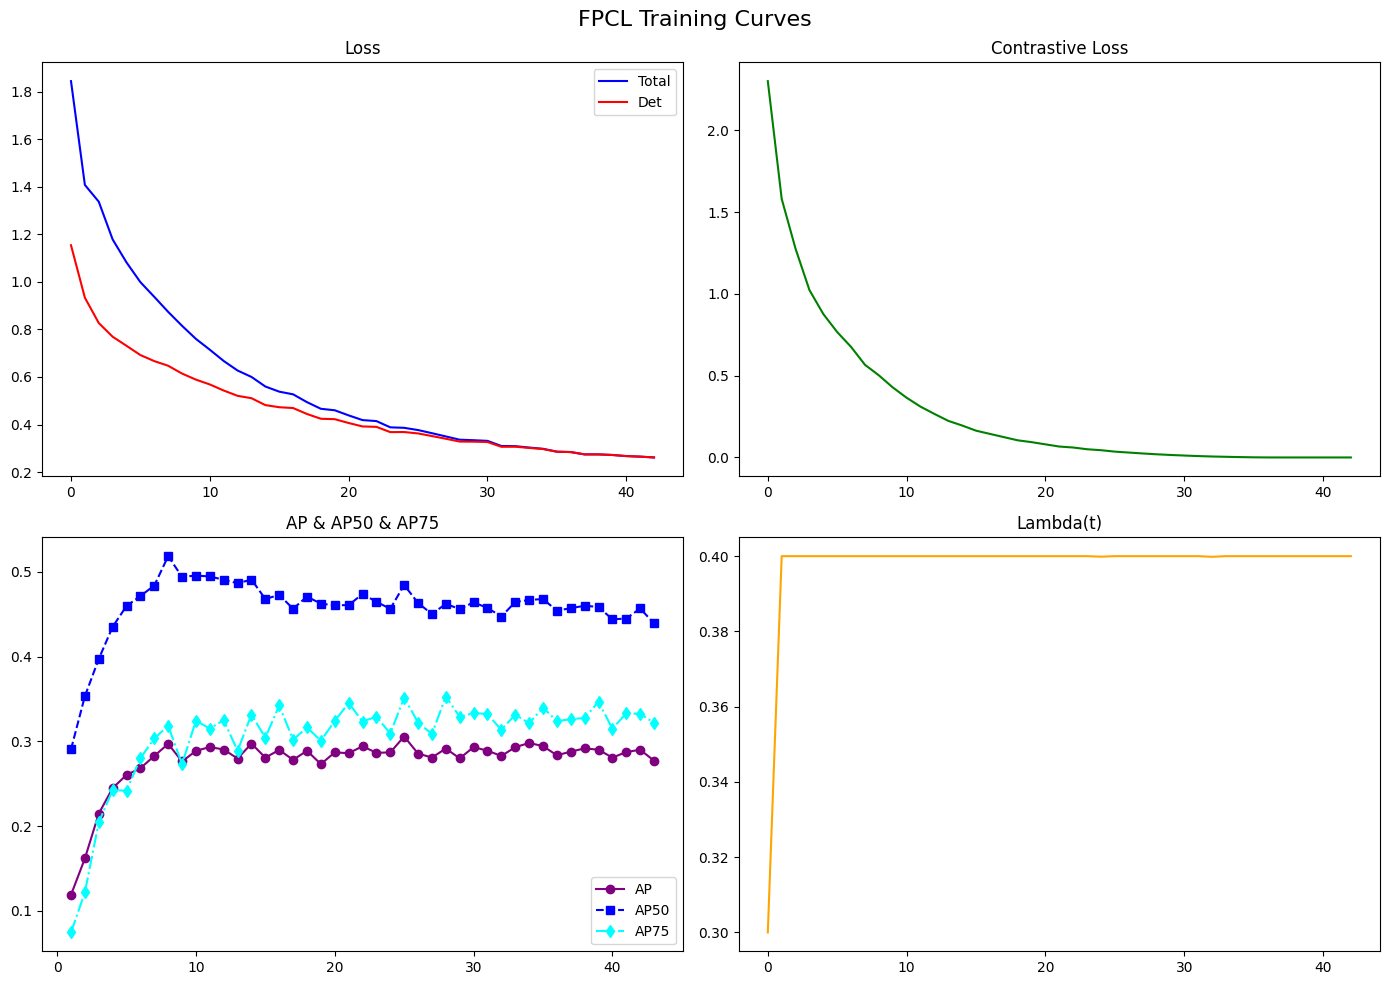

In [10]:
# Load history from checkpoint if not available
if 'history' not in dir() or history is None:
    import os
    _ckpt_path = os.path.join(Config.SAVE_DIR, "best.pth")
    if not os.path.exists(_ckpt_path):
        _ckpt_path = os.path.join(Config.SAVE_DIR, "last.pth")
    _ckpt = torch.load(_ckpt_path, map_location=DEVICE, weights_only=False)
    history = _ckpt.get('hist', None)
    del _ckpt
    if history is None:
        print("No training history found in checkpoints. Skipping plot.")

if history is not None:
    fig, ax = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('FPCL Training Curves', fontsize=16)

    ax[0,0].plot(history['loss'], label='Total', c='b')
    ax[0,0].plot(history['det'], label='Det', c='r')
    ax[0,0].set_title('Loss')
    ax[0,0].legend()

    ax[0,1].plot(history['cl'], c='g')
    ax[0,1].set_title('Contrastive Loss')

    if history['map']:
        eps = [x[0]+1 for x in history['map']]
        ax[1,0].plot(eps, [x[1] for x in history['map']], 'o-', label='AP', c='purple')
        ax[1,0].plot(eps, [x[1] for x in history['ap50']], 's--', label='AP50', c='blue')
        ax[1,0].plot(eps, [x[1] for x in history['ap75']], 'd-.', label='AP75', c='cyan')
        ax[1,0].legend()
    ax[1,0].set_title('AP & AP50 & AP75')

    ax[1,1].plot(history['lam'], c='orange')
    ax[1,1].set_title('Lambda(t)')

    plt.tight_layout()
    plt.savefig(os.path.join(Config.SAVE_DIR, 'hist.png'), dpi=150)
    plt.show()


## Qualitative Visualization

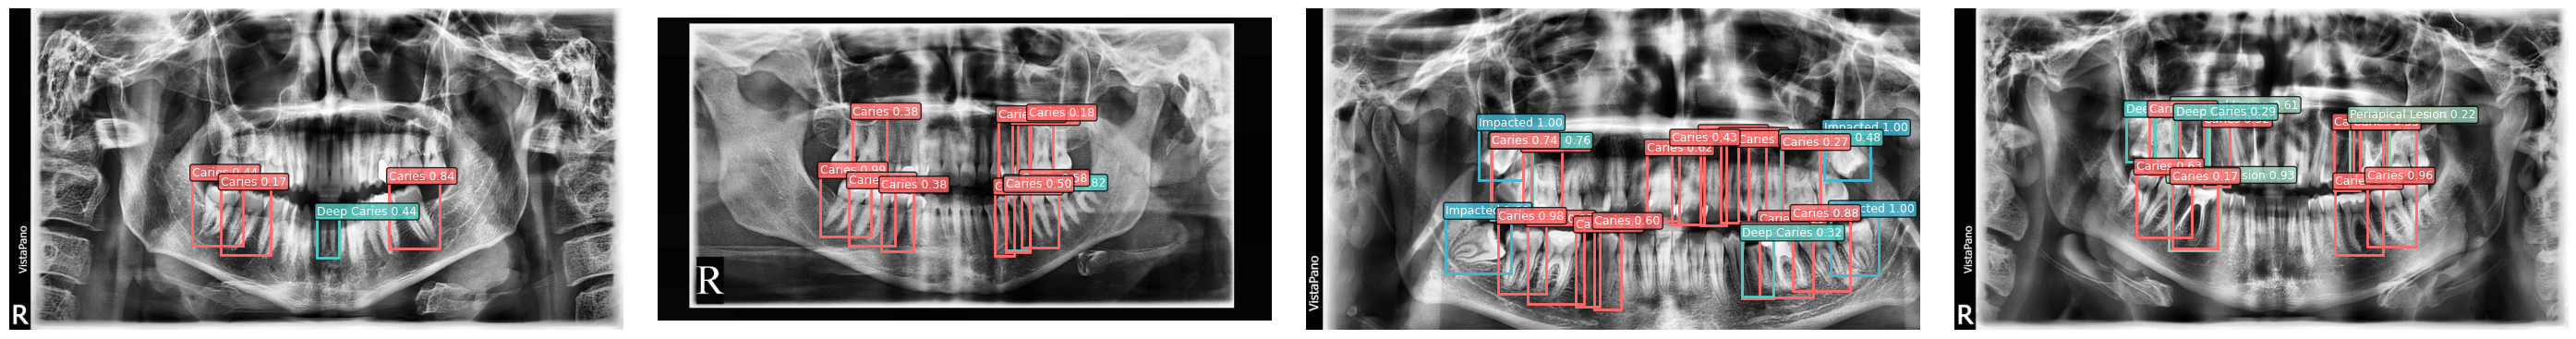

In [11]:
# Auto-load model if not in memory
if 'model' not in dir() or model is None:
    model = FPCLModel(Config.NUM_CLASSES, Config.FPN_DEPTH).to(DEVICE)
    _best_path = os.path.join(Config.SAVE_DIR, "best.pth")
    if os.path.exists(_best_path):
        _ckpt = torch.load(_best_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(_ckpt['model'])
        del _ckpt; gc.collect()
        print("Model loaded from best.pth")
    else:
        _last_path = os.path.join(Config.SAVE_DIR, "last.pth")
        _ckpt = torch.load(_last_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(_ckpt['model'])
        del _ckpt; gc.collect()
        print("Model loaded from last.pth")

# Try to get test samples from global variable, otherwise reload
if 'test_samples_glob' in globals() and test_samples_glob:
    vds = YOLOv8DentexDataset(test_samples_glob, get_transform(False))
else:
    _, _, test_samples = prepare_dataset_splits(Config.BASE_DIR)
    vds = YOLOv8DentexDataset(test_samples, get_transform(False))

model.eval()
cols = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
ids = random.sample(range(len(vds)), min(4, len(vds)))

fig, axes = plt.subplots(1, len(ids), figsize=(7 * len(ids), 7))
if len(ids) == 1: axes = [axes]

for ax, i in zip(axes, ids):
    im, _ = vds[i]
    with torch.no_grad():
        p = model([im.to(DEVICE)])[0]
        
    ax.imshow(im.permute(1,2,0).cpu().numpy())
    
    boxes = p['boxes']
    scores = p['scores']
    labels = p['labels']
    
    if Config.USE_CROSS_CLASS_NMS and len(boxes) > 0:
        keep = torchvision.ops.nms(boxes, scores, iou_threshold=0.5)
        boxes = boxes[keep]
        scores = scores[keep]
        labels = labels[keep]
        
    for b, l, s in zip(boxes.cpu(), labels.cpu(), scores.cpu()):
        if s < 0.15: continue
        x1, y1, x2, y2 = b.numpy()
        c = l.item() - 1
        ax.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1, lw=2, ec=cols[c%4], fc='none'))
        ax.text(x1, y1 - 5, f'{Config.CLASSES[c]} {s:.2f}', fontsize=9, color='w',
                bbox=dict(boxstyle='round,pad=.2', fc=cols[c%4], alpha=.8))
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(Config.SAVE_DIR, 'pred.png'), dpi=150)
plt.show()

## Bounding Box Comparison: Ground Truth vs Prediction

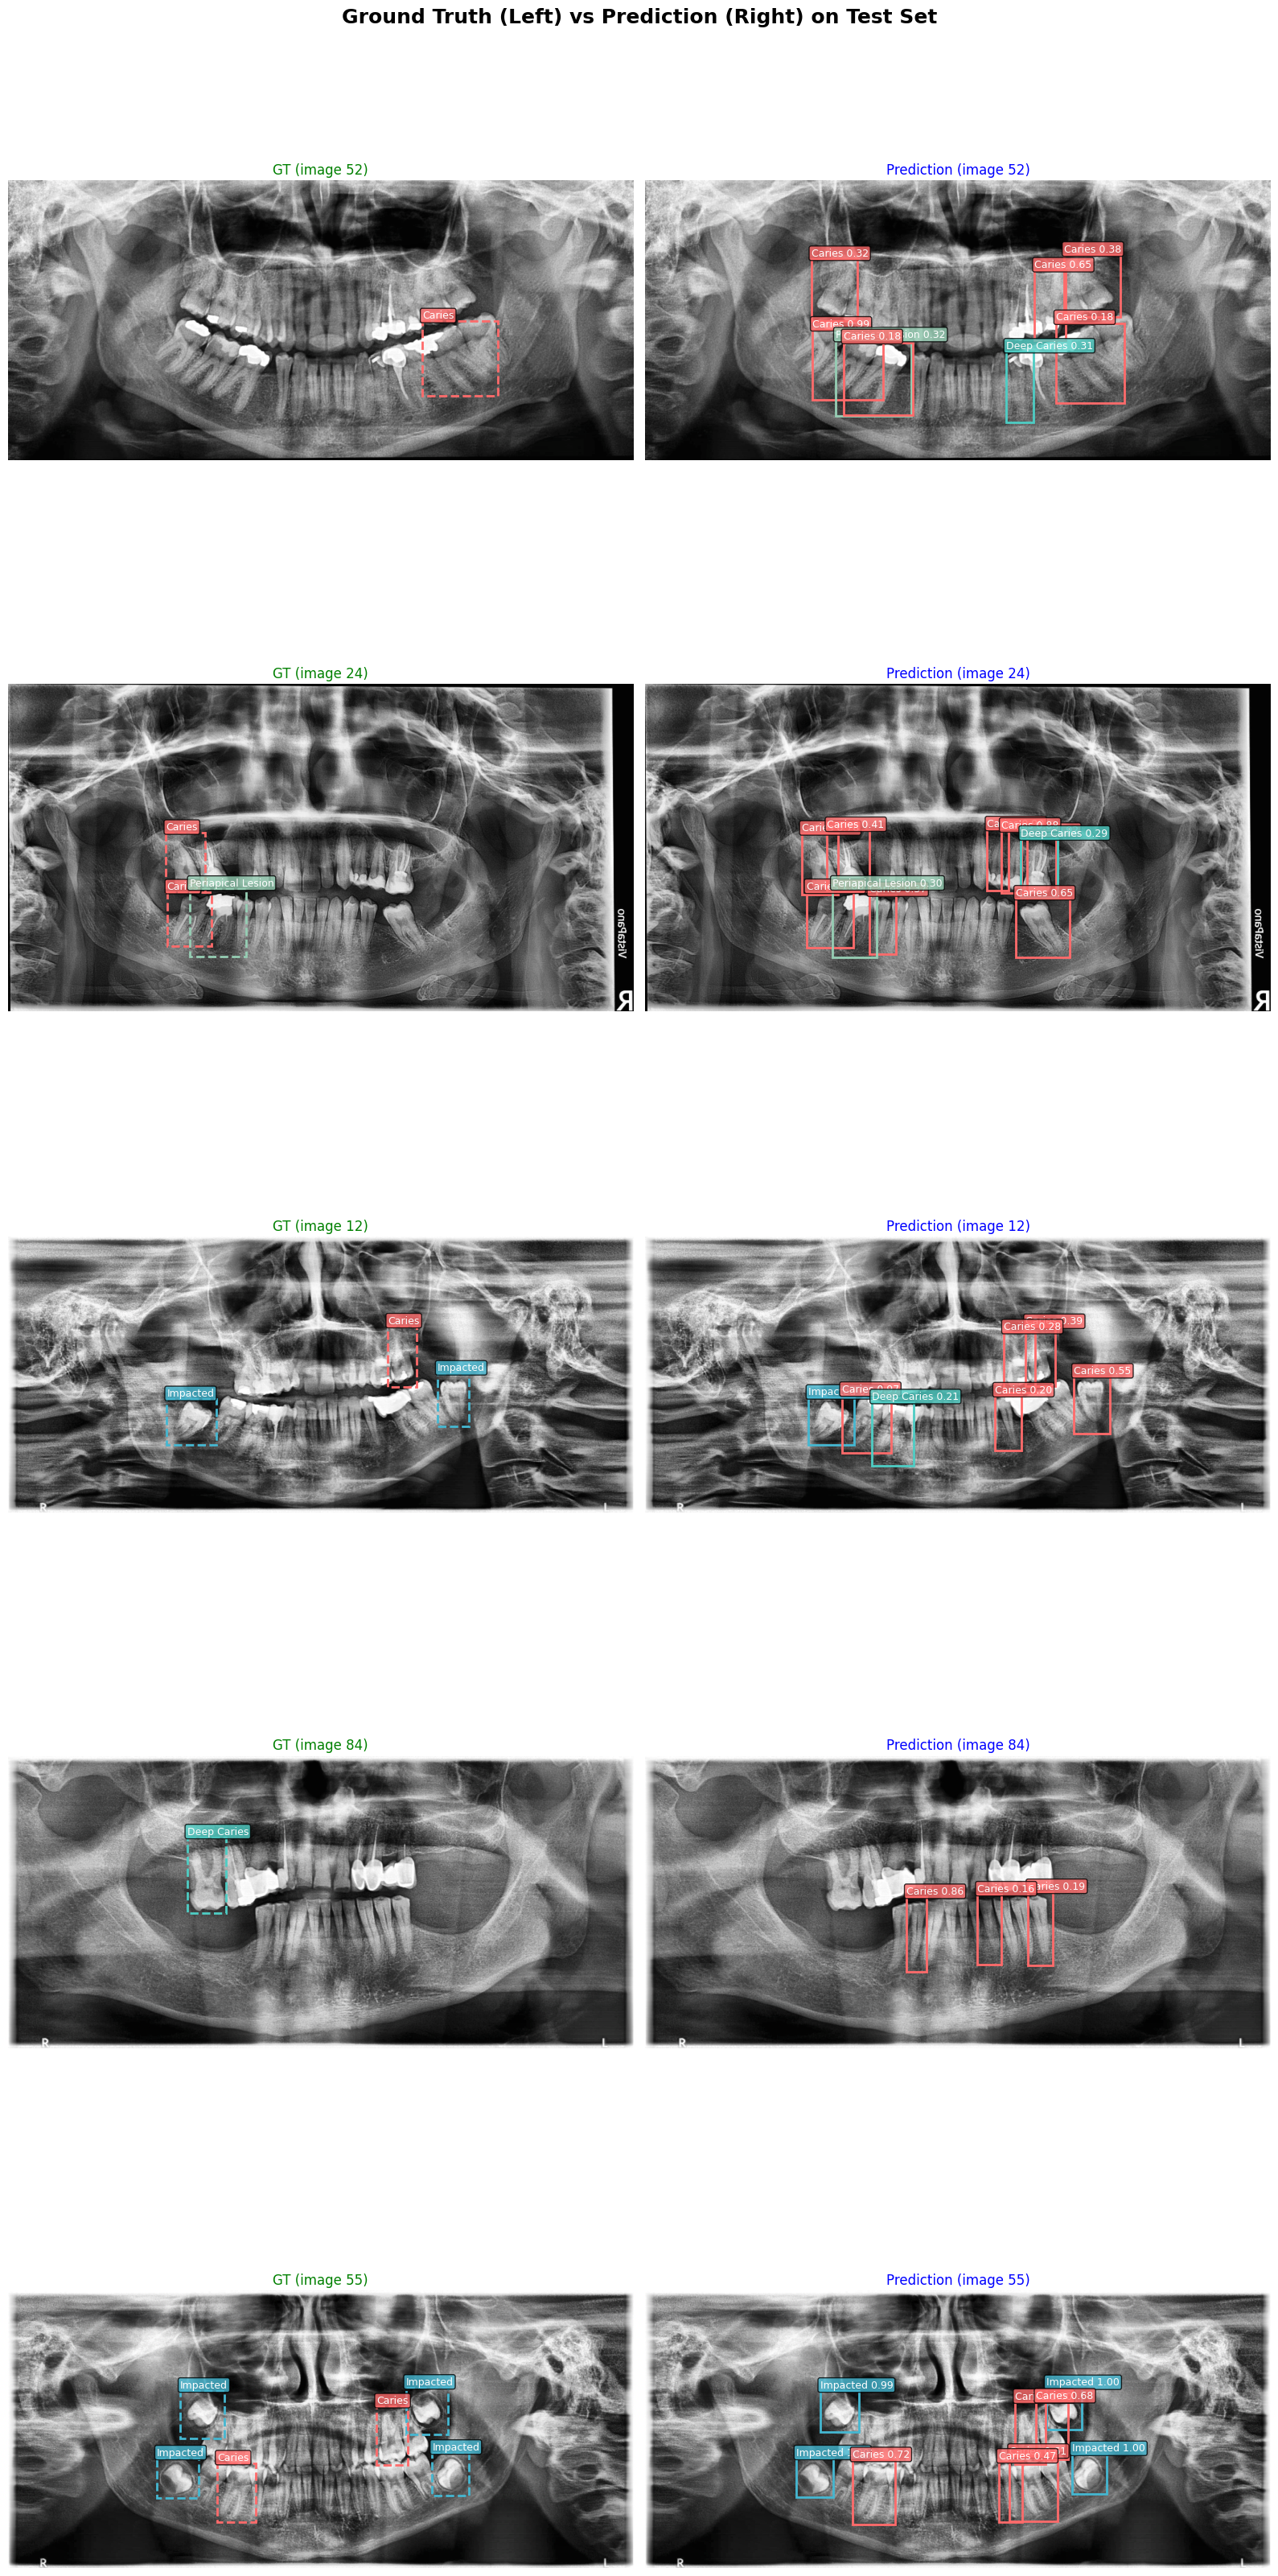

Saved gt_vs_pred.png


In [17]:
# Auto-load model if not in memory
if 'model' not in dir() or model is None:
    model = FPCLModel(Config.NUM_CLASSES, Config.FPN_DEPTH).to(DEVICE)
    _best_path = os.path.join(Config.SAVE_DIR, "best.pth")
    if os.path.exists(_best_path):
        _ckpt = torch.load(_best_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(_ckpt['model'])
        del _ckpt; gc.collect()
        print("Model loaded from best.pth")
    else:
        _last_path = os.path.join(Config.SAVE_DIR, "last.pth")
        _ckpt = torch.load(_last_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(_ckpt['model'])
        del _ckpt; gc.collect()
        print("Model loaded from last.pth")

# Try to get test samples from global variable, otherwise reload
if 'test_samples_glob' in globals() and test_samples_glob:
    vds = YOLOv8DentexDataset(test_samples_glob, get_transform(False))
else:
    _, _, test_samples = prepare_dataset_splits(Config.BASE_DIR)
    vds = YOLOv8DentexDataset(test_samples, get_transform(False))

model.eval()
cols = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
ids = random.sample(range(len(vds)), min(5, len(vds)))

fig, axes = plt.subplots(len(ids), 2, figsize=(16, 7 * len(ids)))
fig.suptitle('Ground Truth (Left) vs Prediction (Right) on Test Set', fontsize=18, fontweight='bold')

for row, idx in enumerate(ids):
    im, tgt = vds[idx]
    img_np = im.permute(1, 2, 0).cpu().numpy()
    
    # --- Left: Ground Truth ---
    ax_gt = axes[row, 0]
    ax_gt.imshow(img_np)
    ax_gt.set_title(f'GT (image {idx})', fontsize=12, color='green')
    for b, l in zip(tgt['boxes'], tgt['labels']):
        x1, y1, x2, y2 = b.numpy()
        c = l.item() - 1
        ax_gt.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1, lw=2, ec=cols[c%4], fc='none', ls='--'))
        ax_gt.text(x1, y1 - 5, Config.CLASSES[c], fontsize=9, color='w',
                   bbox=dict(boxstyle='round,pad=.2', fc=cols[c%4], alpha=.8))
    ax_gt.axis('off')
    
    # --- Right: Prediction ---
    ax_pr = axes[row, 1]
    ax_pr.imshow(img_np)
    ax_pr.set_title(f'Prediction (image {idx})', fontsize=12, color='blue')
    with torch.no_grad():
        pred = model([im.to(DEVICE)])[0]
        
    boxes = pred['boxes']
    scores = pred['scores']
    labels = pred['labels']
    
    if Config.USE_CROSS_CLASS_NMS and len(boxes) > 0:
        keep = torchvision.ops.nms(boxes, scores, iou_threshold=0.5)
        boxes = boxes[keep]
        scores = scores[keep]
        labels = labels[keep]
        
    for b, l, s in zip(boxes.cpu(), labels.cpu(), scores.cpu()):
        if s < 0.15: continue
        x1, y1, x2, y2 = b.numpy()
        c = l.item() - 1
        ax_pr.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1, lw=2, ec=cols[c%4], fc='none'))
        ax_pr.text(x1, y1 - 5, f'{Config.CLASSES[c]} {s:.2f}', fontsize=9, color='w',
                   bbox=dict(boxstyle='round,pad=.2', fc=cols[c%4], alpha=.8))
    ax_pr.axis('off')
    
plt.tight_layout()
plt.savefig(os.path.join(Config.SAVE_DIR, 'gt_vs_pred.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved gt_vs_pred.png")

## Single Image Inference Time and Visualization / Dự đoán 1 ảnh bất kỳ và đo thời gian
This cell selects a random image from the test dataset, measures the inference time in milliseconds (with CUDA synchronization if running on GPU), and displays the Ground Truth bounding boxes side-by-side with the Predicted bounding boxes.

Selected image index / Chỉ số ảnh: 93
Inference time / Thời gian dự đoán: 97.38 ms


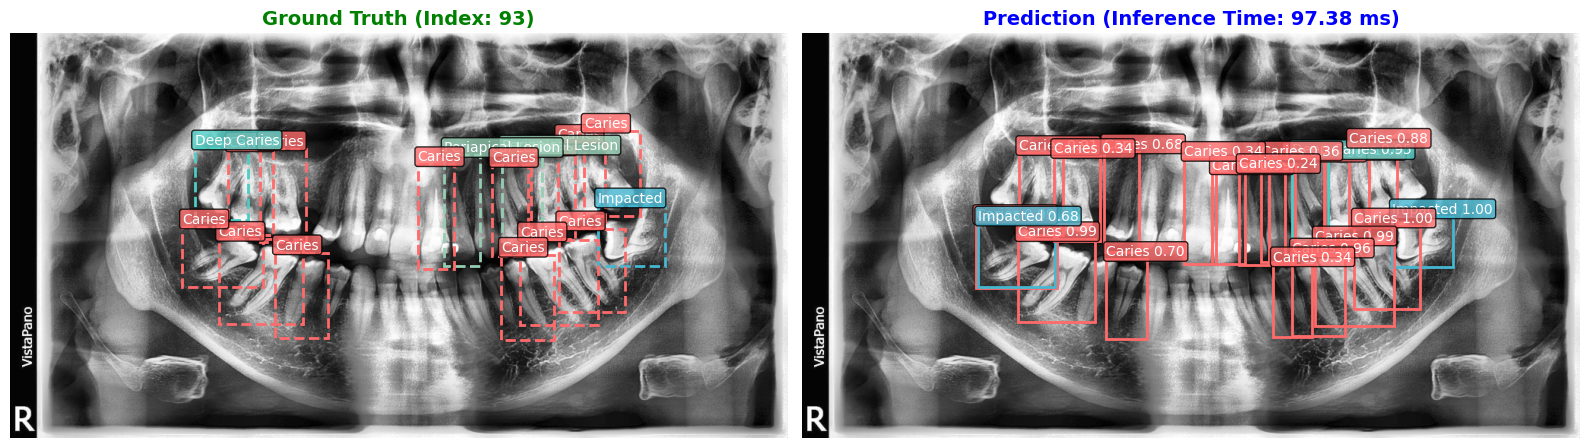

In [23]:
# --- Đo thời gian dự đoán và hiển thị ảnh dự đoán kèm Ground Truth ---
import random
import time
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import os

# 1. Đảm bảo model đã được load
if 'model' not in globals():
    print("Model not found in memory. Instantiating and loading best weights...")
    model = FPCLModel(Config.NUM_CLASSES, Config.FPN_DEPTH).to(DEVICE)
    best_path = os.path.join(Config.SAVE_DIR, "best.pth")
    if os.path.exists(best_path):
        checkpoint_data = torch.load(best_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(checkpoint_data['model'])
        print(f"Loaded weights from {best_path}")
    else:
        print("Warning: best.pth not found, using randomly initialized model.")

# 2. Lấy dataset test
if 'test_samples_glob' in globals() and test_samples_glob:
    vds = YOLOv8DentexDataset(test_samples_glob, get_transform(False))
else:
    _, _, test_samples = prepare_dataset_splits(Config.BASE_DIR)
    vds = YOLOv8DentexDataset(test_samples, get_transform(False))

# 3. Chọn ngẫu nhiên 1 ảnh (hoặc bạn có thể gán cứng idx cụ thể)
idx = random.randint(0, len(vds) - 1)
print(f"Selected image index / Chỉ số ảnh: {idx}")

im, tgt = vds[idx]
img_np = im.permute(1, 2, 0).cpu().numpy()

# 4. Đo thời gian dự đoán (Inference time)
model.eval()
device = next(model.parameters()).device

# Chạy nháp 1 lần (Warmup) để tránh tính thời gian khởi tạo hoặc load GPU
with torch.no_grad():
    _ = model([im.to(device)])

if device.type == 'cuda':
    torch.cuda.synchronize()
start_time = time.perf_counter()

with torch.no_grad():
    pred = model([im.to(device)])[0]

if device.type == 'cuda':
    torch.cuda.synchronize()
end_time = time.perf_counter()
inf_time_ms = (end_time - start_time) * 1000
print(f"Inference time / Thời gian dự đoán: {inf_time_ms:.2f} ms")

# 5. Vẽ ảnh Ground Truth và Predicted cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
cols = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

# --- Bên trái: Ground Truth ---
ax_gt = axes[0]
ax_gt.imshow(img_np)
ax_gt.set_title(f'Ground Truth (Index: {idx})', fontsize=14, color='green', fontweight='bold')
for b, l in zip(tgt['boxes'], tgt['labels']):
    x1, y1, x2, y2 = b.numpy()
    c = l.item() - 1
    ax_gt.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1, lw=2, ec=cols[c%4], fc='none', ls='--'))
    ax_gt.text(x1, y1 - 5, Config.CLASSES[c], fontsize=10, color='w',
               bbox=dict(boxstyle='round,pad=.2', fc=cols[c%4], alpha=.8))
ax_gt.axis('off')

# --- Bên phải: Dự đoán (Prediction) ---
ax_pr = axes[1]
ax_pr.imshow(img_np)
ax_pr.set_title(f'Prediction (Inference Time: {inf_time_ms:.2f} ms)', fontsize=14, color='blue', fontweight='bold')

boxes = pred['boxes']
scores = pred['scores']
labels = pred['labels']

if Config.USE_CROSS_CLASS_NMS and len(boxes) > 0:
    keep = torchvision.ops.nms(boxes, scores, iou_threshold=0.5)
    boxes = boxes[keep]
    scores = scores[keep]
    labels = labels[keep]

for b, l, s in zip(boxes.cpu(), labels.cpu(), scores.cpu()):
    if s < 0.15: continue
    x1, y1, x2, y2 = b.numpy()
    c = l.item() - 1
    ax_pr.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1, lw=2, ec=cols[c%4], fc='none'))
    ax_pr.text(x1, y1 - 5, f'{Config.CLASSES[c]} {s:.2f}', fontsize=10, color='w',
               bbox=dict(boxstyle='round,pad=.2', fc=cols[c%4], alpha=.8))
ax_pr.axis('off')

plt.tight_layout()
plt.show()


Tong so nhom anh goc trong Train: 548
Tong so anh sach trong Evaluation Pool: 230 (100 tu train + 130 tu valid goc)
Da phan chia tranh Data Leak (Val & Test bang nhau, co oversampling):
  - Train: 2277 files (da oversample tu 448 nhom)
  - Val:   115 files (sach, khong augmented)
  - Test:  115 files (sach, khong augmented)
Scanning test set (115 images) to find the best prediction...


Inference: 100%|██████████| 115/115 [00:12<00:00,  9.11it/s]



Done! Best matching score: 0.8948 found at test index: 36


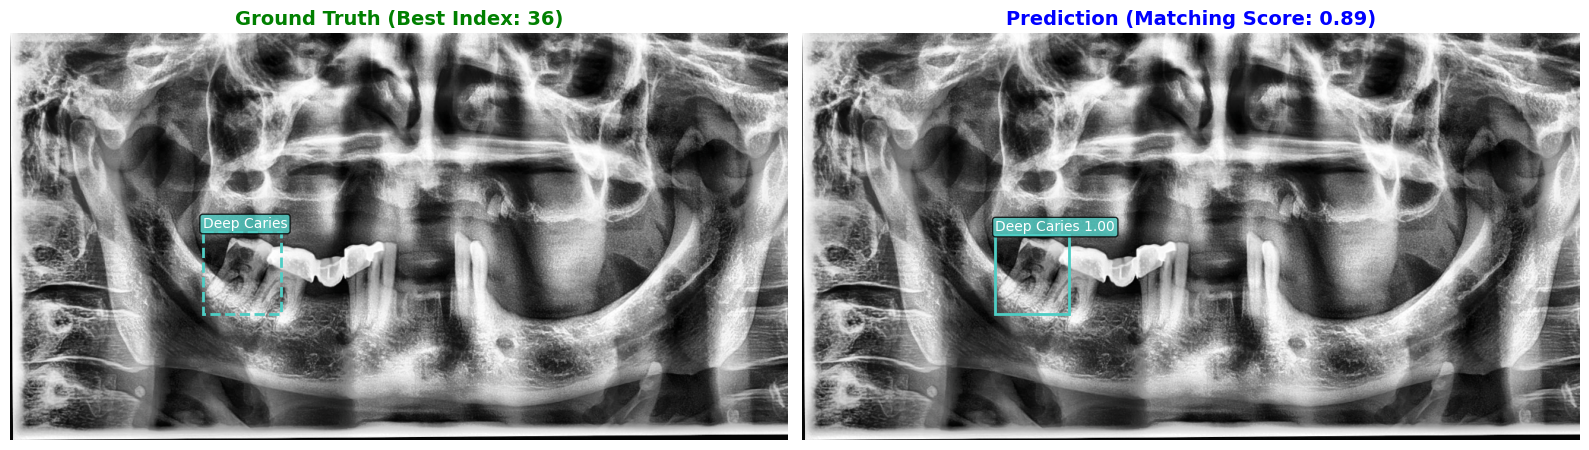

In [14]:
# --- Tìm và hiển thị ảnh dự đoán chính xác nhất so với Ground Truth trên tập Test ---
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import os
from tqdm import tqdm

# 1. Đảm bảo model đã được load ở chế độ eval
if 'model' not in globals() or model is None:
    print("Loading best model weights...")
    model = FPCLModel(Config.NUM_CLASSES, Config.FPN_DEPTH).to(DEVICE)
    best_path = os.path.join(Config.SAVE_DIR, "best.pth")
    if os.path.exists(best_path):
        checkpoint_data = torch.load(best_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(checkpoint_data['model'])
        print(f"Loaded weights from {best_path}")
    else:
        print("Warning: best.pth not found!")
model.eval()

# 2. Lấy dataset test
if 'test_samples' not in globals():
    _, _, test_samples = prepare_dataset_splits(Config.BASE_DIR)
vds_test = YOLOv8DentexDataset(test_samples, get_transform(False))

print(f"Scanning test set ({len(vds_test)} images) to find the best prediction...")

best_score = -1.0
best_idx = -1
best_predictions = None
best_target = None

# Hàm tính IoU giữa 2 box (x1, y1, x2, y2)
def compute_single_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / (union + 1e-6)

# Duyệt qua toàn bộ tập test để tìm ảnh có điểm khớp tốt nhất
with torch.no_grad():
    for idx in tqdm(range(len(vds_test)), desc="Inference"):
        im, tgt = vds_test[idx]
        gt_boxes = tgt['boxes'].cpu()
        gt_labels = tgt['labels'].cpu()
        
        # Chỉ xét các ảnh thực sự có nhãn tổn thương
        if len(gt_boxes) == 0:
            continue
            
        preds = model([im.to(DEVICE)])[0]
        pred_boxes = preds['boxes'].cpu()
        pred_scores = preds['scores'].cpu()
        pred_labels = preds['labels'].cpu()
        
        # Lọc dự đoán theo ngưỡng tự tin 0.15
        keep = pred_scores >= 0.15
        pred_boxes = pred_boxes[keep]
        pred_labels = pred_labels[keep]
        pred_scores = pred_scores[keep]
        
        N_gt = len(gt_boxes)
        N_pred = len(pred_boxes)
        
        total_iou = 0.0
        matched_gt = set()
        
        # So sánh khớp cặp giữa dự đoán và nhãn thực tế
        for p_idx, (p_box, p_lbl) in enumerate(zip(pred_boxes, pred_labels)):
            best_iou_for_pred = 0.0
            best_gt_idx = -1
            for g_idx, (g_box, g_lbl) in enumerate(zip(gt_boxes, gt_labels)):
                if g_lbl == p_lbl and g_idx not in matched_gt:
                    iou = compute_single_iou(p_box.numpy(), g_box.numpy())
                    if iou > best_iou_for_pred:
                        best_iou_for_pred = iou
                        best_gt_idx = g_idx
            if best_gt_idx != -1 and best_iou_for_pred >= 0.5:
                total_iou += best_iou_for_pred
                matched_gt.add(best_gt_idx)
                
        # Điểm số kết hợp trung bình IoU phạt theo số lượng hộp dư/thiếu
        score = total_iou / max(N_gt, N_pred, 1)
        
        if score > best_score:
            best_score = score
            best_idx = idx
            best_predictions = {'boxes': pred_boxes, 'labels': pred_labels, 'scores': pred_scores}
            best_target = tgt

print(f"\nDone! Best matching score: {best_score:.4f} found at test index: {best_idx}")

# 3. Trực quan hóa ảnh có dự đoán khớp tốt nhất
im, tgt = vds_test[best_idx]
img_np = im.permute(1, 2, 0).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
cols = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

# --- Bên trái: Ground Truth ---
ax_gt = axes[0]
ax_gt.imshow(img_np)
ax_gt.set_title(f'Ground Truth (Best Index: {best_idx})', fontsize=14, color='green', fontweight='bold')
for b, l in zip(tgt['boxes'], tgt['labels']):
    x1, y1, x2, y2 = b.numpy()
    c = l.item() - 1
    ax_gt.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1, lw=2, ec=cols[c%4], fc='none', ls='--'))
    ax_gt.text(x1, y1 - 5, Config.CLASSES[c], fontsize=10, color='w',
               bbox=dict(boxstyle='round,pad=.2', fc=cols[c%4], alpha=.8))
ax_gt.axis('off')

# --- Bên phải: Dự đoán (Prediction) ---
ax_pr = axes[1]
ax_pr.imshow(img_np)
ax_pr.set_title(f'Prediction (Matching Score: {best_score:.2f})', fontsize=14, color='blue', fontweight='bold')
for b, l, s in zip(best_predictions['boxes'], best_predictions['labels'], best_predictions['scores']):
    x1, y1, x2, y2 = b.numpy()
    c = l.item() - 1
    ax_pr.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1, lw=2, ec=cols[c%4], fc='none'))
    ax_pr.text(x1, y1 - 5, f'{Config.CLASSES[c]} {s:.2f}', fontsize=10, color='w',
               bbox=dict(boxstyle='round,pad=.2', fc=cols[c%4], alpha=.8))
ax_pr.axis('off')

plt.tight_layout()
plt.show()
